## **Dataset Loading  and Understanding**

In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Load the product behavior dataset.
# low_memory=False helps Pandas infer data types more consistently on large CSV files.

file_path = "../data/2019-Oct.csv"

df = pd.read_csv(
    file_path,
    low_memory=False
)

In [3]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [4]:
# Check dataset size: number of rows and columns.
df.shape

(42448764, 9)

**Inspect column names, data types, and missing values.**

In [ ]:
# Inspect column names, data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.8 GB


In [ ]:
# Convert the "event_time" column to datetime format for easier time-based analysis.
df["event_time"] = pd.to_datetime(df["event_time"])

In [9]:
df["event_time"].dtype

datetime64[us, UTC]

In [6]:
# Count missing values per column.
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

In [25]:
# Preview event types such as view, cart, purchase.
event_summary = df["event_type"].value_counts().reset_index()

In [26]:
# display events types and their counts
event_summary

,event_type,count
0,view,40779399
1,cart,926516
2,purchase,742849


`event_type` describes the type of user interaction recorded in each row.

In this dataset, the main event types are:

| event_type | Meaning |
|---|---|
| `view` | The user viewed a product |
| `cart` | The user added a product to the cart |
| `purchase` | The user completed a purchase |

These events can be interpreted as stages in a possible customer journey:

view → cart → purchase

However, this does not mean every user follows this exact order. Some users may only view products, some may add products to cart without purchasing, and some purchases may appear without a previous cart event inside the available dataset period.

---
### **Product Behavior Analysis**

In [27]:
# Count each user action type.
event_summary

,event_type,count
0,view,40779399
1,cart,926516
2,purchase,742849


**Event Distribution Visualization**

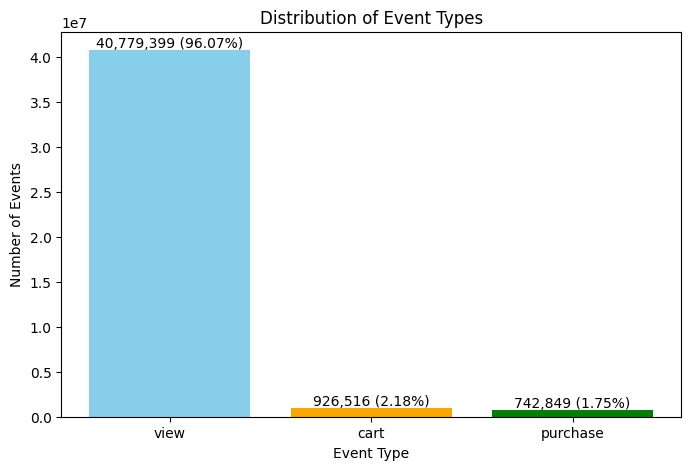

In [48]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    event_summary["event_type"],
    event_summary["count"],
    color=["skyblue", "orange", "green"]
)


plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f} ({height/(event_summary['count'].sum()):.2%})",
        ha="center",
        va="bottom"
    )

plt.show()

**Dominant Event Type**

The `view` event overwhelmingly dominates the dataset, accounting for approximately `96%` of all recorded events. This indicates that most user interactions involve browsing products rather than taking actions closer to a purchase.

**Purchase Frequency**

Purchasing is relatively rare. `purchase` events represent only about `1.75%` of all recorded events, making them one of the least frequent user actions in the dataset.

**Expected E-Commerce Behavior**

This pattern is expected in e-commerce because customers typically browse many products before making a purchase decision. Most visitors explore product pages, compare alternatives, and leave the website without completing a transaction. As a result, `view` events naturally occur much more frequently than `purchase` events.

 **Gap Between Views and Purchases**

A large gap between `view` and `purchase` events suggests a significant drop-off throughout the customer journey. While many users show interest in products by viewing them, only a small proportion proceed to purchase. This may indicate friction in the buying process, price sensitivity, lack of purchase intent, or opportunities to improve the overall shopping experience.

 **Business Opportunities**

The large volume of product views creates several opportunities for the business:

- Improve `conversion rates` by optimizing product pages and checkout processes.
- Identify products that receive substantial attention but generate relatively few purchases.
- Implement `retargeting campaigns` for users who viewed products but did not convert.
- Use `personalized recommendations` to encourage further engagement and purchases.
- Analyze `customer behavior` to better understand where users abandon the purchasing journey.

Given the extremely high number of product views, even a modest improvement in the `conversion rate (Purchases/Views)` could result in a meaningful increase in sales and revenue.

**Funnel Metrics and Conversion Rates**

In [ ]:
views = (df["event_type"] == "view").sum()
carts = (df["event_type"] == "cart").sum()
purchases = (df["event_type"] == "purchase").sum()
funnel_df = pd.DataFrame({
    "Stage": [
        "View",
        "Cart",
        "Purchase"
    ],
    "Users": [
        views,
        carts,
        purchases
    ]
})
funnel_df

,Stage,Users
0,View,40779399
1,Cart,926516
2,Purchase,742849


In [ ]:
view_to_cart = carts / views * 100
cart_to_purchase = purchases / carts * 100
view_to_purchase = purchases / views * 100

conversion_summary = pd.DataFrame({
    "Metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase"
    ],
    "Conversion Rate (%)": [
        round(view_to_cart, 2),
        round(cart_to_purchase, 2),
        round(view_to_purchase, 2)
    ]
})

conversion_summary

,Metric,Conversion Rate (%)
0,View → Cart,2.27
1,Cart → Purchase,80.18
2,View → Purchase,1.82


**Biggest Funnel Drop-Off**

The largest drop-off occurs between `view` and `cart` events. Many users browse products, but only a small percentage add items to their cart.

**Potential Reasons for Abandonment**

Possible reasons include high prices, lack of purchase intent, insufficient product information, or concerns about shipping and delivery.

**Product Improvement Opportunities**

- Improve `product descriptions` and images.
- Increase visibility of `reviews` and ratings.
- Offer promotions and personalized recommendations.
- Simplify the shopping experience.

**Key Weekly Executive Metric**

The most important metric is the `view-to-cart conversion rate`, as it measures how effectively product views turn into buying intent.

**Value of Funnel Analysis**

`Funnel analysis` identifies where customers drop off in the purchasing journey, helping the business target improvements more effectively than revenue metrics alone.

---

## **User Analytics**

**User Engagement KPIs**

In [62]:
# Count unique users in the platform.

unique_users = df["user_id"].nunique()
unique_sessions = df["user_session"].nunique()
summary_df = pd.DataFrame({
    "KPI": [
        "Total Events",
        "Unique Users",
        "Average Events per User",
        "Average Events per Session",
        "Average Sessions per User"
    ],
    "Value": [
        len(df),
        unique_users,
        round(len(df) / unique_users, 2),
        round(len(df) / unique_sessions, 2),
        round(unique_sessions / unique_users, 2)
    ]
})


In [63]:
summary_df

,KPI,Value
0,Total Events,42448764.00
1,Unique Users,3022290.00
2,Average Events per User,14.05
3,Average Events per Session,4.59
4,Average Sessions per User,3.06


**User Activity Distribution**

In [82]:
user_activity = (
    df.groupby(["user_id"])
      .size()
      .reset_index(name="EventCount")
)

In [83]:
user_activity

,user_id,EventCount
0,33869381,1
1,64078358,1
2,183503497,1
3,184265397,6
4,195082191,1
...,...,...
3022285,566280663,2
3022286,566280676,1
3022287,566280697,1
3022288,566280780,1


**Most Active Users**

In [84]:
top_users = (
    user_activity
    .sort_values(
        by=["EventCount"],
        ascending=False
    )
    .head(20)
)

top_users

,user_id,EventCount
40079,512475445,7436
21430,512365995,4013
976096,526731152,2912
44956,512505687,2894
123300,513021392,2862
1584320,546159478,2433
1588795,546270188,2426
310296,514649263,2390
470249,516308435,2316
27810,512401084,2232


**Engagement Visualization**

In [117]:
import seaborn as sns

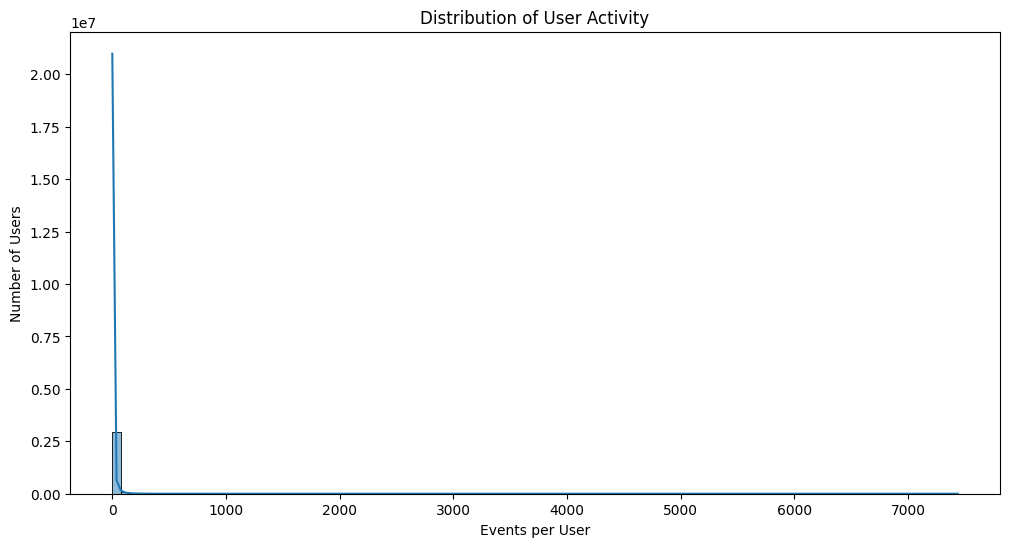

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.histplot(
    user_activity["EventCount"],
    bins=100,
    kde=True
)

plt.title("Distribution of User Activity")
plt.xlabel("Events per User")
plt.ylabel("Number of Users")

plt.show()

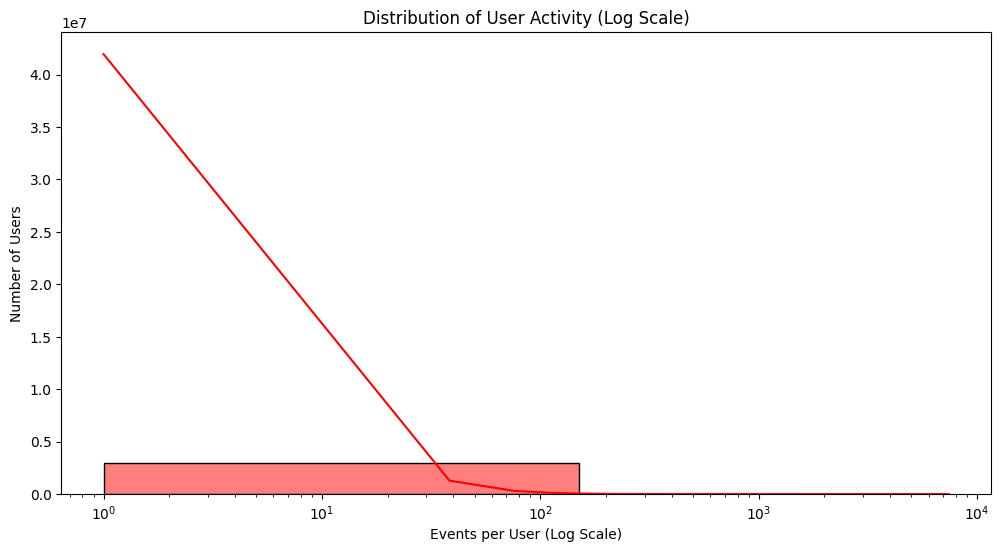

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    user_activity["EventCount"],
    bins=50, # fewer bins to show the skewed distribution more clearly
    color="red",
    kde=True
)

# Data is Highly Skewed - Log Scale Helps Visualize the Distribution Better
# more readable x-axis for skewed data 
plt.xscale("log")

plt.title("Distribution of User Activity (Log Scale)")
plt.xlabel("Events per User (Log Scale)")
plt.ylabel("Number of Users")

plt.show()

---

## **Retention and Cohort Analysis**

---

## **Churn Analytics**

---

## **Product KPI Dashboard**

---

## **Executive Storytelling**